In [1]:
import matplotlib.pyplot as plt
import pandas as pd

For this exercise, you will be using the CDC PLACES county dataset [here](https://data.cdc.gov/500-Cities-Places/PLACES-County-Data-GIS-Friendly-Format-2025-releas/i46a-9kgh/about_data). This data contains various health indicators by county.<br>
Import this data using their API and filter for Indiana records. View your dataset. Take note the columns, and ensure that all 92 counties were retrieved.

In [2]:
df = pd.read_csv('https://data.cdc.gov/resource/i46a-9kgh.csv?$limit=4000').query('stateabbr == "IN"').reset_index(drop = True)
df

,stateabbr,statedesc,countyname,countyfips,totalpopulation,totalpop18plus,access2_crudeprev,access2_crude95ci,access2_adjprev,access2_adj95ci,...,shututility_adj95ci,lacktrpt_crudeprev,lacktrpt_crude95ci,lacktrpt_adjprev,lacktrpt_adj95ci,emotionspt_crudeprev,emotionspt_crude95ci,emotionspt_adjprev,emotionspt_adj95ci,geolocation
0,IN,Indiana,Perry,18123,19209,15282,8.5,"( 6.6, 11.0)",8.9,"( 6.7, 11.4)",...,"( 7.0, 9.9)",7.2,"( 6.0, 8.5)",7.7,"( 6.4, 9.1)",23.7,"(19.6, 28.0)",24.5,"(20.3, 28.9)",POINT (-86.6381199530206 38.079509981274)
1,IN,Indiana,Tippecanoe,18157,188792,150623,8.6,"( 6.6, 11.0)",8.8,"( 7.0, 10.7)",...,"( 7.7, 10.9)",8.3,"( 6.9, 10.1)",8.0,"( 6.8, 9.5)",23.1,"(19.6, 27.1)",22.7,"(19.4, 26.4)",POINT (-86.8940552546538 40.3886239103306)
2,IN,Indiana,Porter,18127,175335,138304,8.3,"( 6.6, 10.5)",8.7,"( 6.9, 11.1)",...,"( 6.4, 9.0)",6.5,"( 5.4, 7.6)",6.9,"( 5.8, 8.2)",21.8,"(18.7, 25.1)",22.5,"(19.3, 26.0)",POINT (-87.0674513182353 41.4608374022855)
3,IN,Indiana,Hendricks,18063,186387,140883,6.9,"( 5.3, 8.9)",7.1,"( 5.4, 9.2)",...,"( 5.6, 7.9)",5.8,"( 4.9, 6.9)",6.1,"( 5.1, 7.2)",20.4,"(17.3, 23.8)",20.8,"(17.6, 24.3)",POINT (-86.5099930674506 39.7695155217637)
4,IN,Indiana,Kosciusko,18085,80364,61628,9.2,"( 7.2, 11.7)",9.6,"( 7.5, 12.3)",...,"( 6.6, 9.5)",7.1,"( 5.9, 8.4)",7.6,"( 6.3, 9.0)",22.3,"(18.8, 25.9)",23.0,"(19.4, 26.8)",POINT (-85.8607456885205 41.2441073982605)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,IN,Indiana,Knox,18083,36070,28282,8.3,"( 6.4, 10.7)",8.7,"( 6.7, 11.2)",...,"( 7.4, 10.4)",7.7,"( 6.5, 9.1)",8.1,"( 6.8, 9.6)",23.5,"(19.9, 27.6)",24.2,"(20.3, 28.2)",POINT (-87.4186758135076 38.6897913410139)
88,IN,Indiana,Fulton,18049,20358,15626,9.4,"( 7.4, 12.0)",9.9,"( 7.7, 12.7)",...,"( 7.5, 10.5)",7.6,"( 6.4, 8.9)",8.3,"( 6.9, 9.8)",22.6,"(19.2, 26.4)",23.5,"(19.9, 27.4)",POINT (-86.2635207365853 41.0469832521579)
89,IN,Indiana,Sullivan,18153,20757,16872,9.5,"( 7.2, 12.2)",9.7,"( 7.4, 12.5)",...,"( 8.4, 11.8)",8.5,"( 7.2, 10.1)",9.0,"( 7.5, 10.8)",23.3,"(19.6, 27.3)",24.0,"(20.1, 28.1)",POINT (-87.4139985670225 39.0890540078366)
90,IN,Indiana,Noble,18113,47430,36001,10.5,"( 8.3, 13.1)",11.0,"( 8.6, 13.7)",...,"( 6.8, 9.8)",7.5,"( 6.2, 8.9)",8.0,"( 6.5, 9.5)",23.3,"(19.3, 27.2)",23.9,"(19.8, 28.0)",POINT (-85.4175453196001 41.3985984916063)


The 7th column onward are all health indicators. We will focus on the adjusted prevalence indicators. Remove all the health indicator columns that do not have the "_adjprev" tag, and remove the tag from these columns.

In [3]:
df = df[list(df.columns)[:6] + [c for c in df if c.endswith('_adjprev')]]
df.columns = df.columns.str.replace('_adjprev', '')
df

,stateabbr,statedesc,countyname,countyfips,totalpopulation,totalpop18plus,access2,arthritis,binge,bphigh,...,selfcare,indeplive,disability,loneliness,foodstamp,foodinsecu,housinsecu,shututility,lacktrpt,emotionspt
0,IN,Indiana,Perry,18123,19209,15282,8.9,26.1,18.7,35.8,...,3.4,8.2,30.9,33.8,8.3,14.1,11.3,8.4,7.7,24.5
1,IN,Indiana,Tippecanoe,18157,188792,150623,8.8,24.8,16.2,33.5,...,3.5,7.8,28.3,32.1,9.1,15.0,11.9,9.2,8.0,22.7
2,IN,Indiana,Porter,18127,175335,138304,8.7,24.8,17.3,34.3,...,2.9,6.9,27.8,32.1,6.8,13.0,10.9,7.7,6.9,22.5
3,IN,Indiana,Hendricks,18063,186387,140883,7.1,24.2,17.7,32.6,...,2.6,6.3,25.2,30.4,5.6,10.6,9.4,6.7,6.1,20.8
4,IN,Indiana,Kosciusko,18085,80364,61628,9.6,25.7,18.3,35.5,...,3.3,7.9,29.5,32.5,7.7,14.2,11.3,8.0,7.6,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,IN,Indiana,Knox,18083,36070,28282,8.7,26.2,17.3,35.1,...,3.6,8.6,32.1,33.9,9.2,15.2,11.9,8.9,8.1,24.2
88,IN,Indiana,Fulton,18049,20358,15626,9.9,26.8,17.9,34.9,...,3.7,9.0,33.2,33.1,9.5,15.9,12.3,9.0,8.3,23.5
89,IN,Indiana,Sullivan,18153,20757,16872,9.7,26.9,17.7,37.1,...,4.0,9.2,33.4,32.9,10.7,17.3,13.1,10.0,9.0,24.0
90,IN,Indiana,Noble,18113,47430,36001,11.0,24.9,18.3,33.1,...,3.5,8.3,31.3,32.5,8.4,15.3,12.1,8.3,8.0,23.9


Now retrieve the data dictionary [here](https://data.cdc.gov/500-Cities-Places/PLACES-and-500-Cities-Data-Dictionary/m35w-spkz/about_data). Take a look at it and note how it relates to the main dataset. Use the data dictionary to rename the health indicator columns to their short names ("measure_short_name" in the data dictionary).

In [4]:
data_dict = pd.read_csv('https://data.cdc.gov/resource/m35w-spkz.csv')
data_dict = {k: v for k, v in zip(data_dict['measureid'].str.lower(), data_dict['measure_short_name'])}
df = df.rename(columns = data_dict)
df

,stateabbr,statedesc,countyname,countyfips,totalpopulation,totalpop18plus,Health Insurance,Arthritis,Binge Drinking,High Blood Pressure,...,Self-care Disability,Independent Living Disability,Any Disability,loneliness,Food Stamps,Food Insecurity,Housing Insecurity,Utilities Services Threat,Transportation Barriers,Lack of Social/Emotional Support
0,IN,Indiana,Perry,18123,19209,15282,8.9,26.1,18.7,35.8,...,3.4,8.2,30.9,33.8,8.3,14.1,11.3,8.4,7.7,24.5
1,IN,Indiana,Tippecanoe,18157,188792,150623,8.8,24.8,16.2,33.5,...,3.5,7.8,28.3,32.1,9.1,15.0,11.9,9.2,8.0,22.7
2,IN,Indiana,Porter,18127,175335,138304,8.7,24.8,17.3,34.3,...,2.9,6.9,27.8,32.1,6.8,13.0,10.9,7.7,6.9,22.5
3,IN,Indiana,Hendricks,18063,186387,140883,7.1,24.2,17.7,32.6,...,2.6,6.3,25.2,30.4,5.6,10.6,9.4,6.7,6.1,20.8
4,IN,Indiana,Kosciusko,18085,80364,61628,9.6,25.7,18.3,35.5,...,3.3,7.9,29.5,32.5,7.7,14.2,11.3,8.0,7.6,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,IN,Indiana,Knox,18083,36070,28282,8.7,26.2,17.3,35.1,...,3.6,8.6,32.1,33.9,9.2,15.2,11.9,8.9,8.1,24.2
88,IN,Indiana,Fulton,18049,20358,15626,9.9,26.8,17.9,34.9,...,3.7,9.0,33.2,33.1,9.5,15.9,12.3,9.0,8.3,23.5
89,IN,Indiana,Sullivan,18153,20757,16872,9.7,26.9,17.7,37.1,...,4.0,9.2,33.4,32.9,10.7,17.3,13.1,10.0,9.0,24.0
90,IN,Indiana,Noble,18113,47430,36001,11.0,24.9,18.3,33.1,...,3.5,8.3,31.3,32.5,8.4,15.3,12.1,8.3,8.0,23.9


Create a correlation matrix to show the relationship between all health indicators.

In [5]:
df.iloc[:, 6:].corr()

,Health Insurance,Arthritis,Binge Drinking,High Blood Pressure,High Blood Pressure Medication,Cancer (non-skin) or melanoma,Current Asthma,Coronary Heart Disease,Annual Checkup,Cholesterol Screening,...,Self-care Disability,Independent Living Disability,Any Disability,loneliness,Food Stamps,Food Insecurity,Housing Insecurity,Utilities Services Threat,Transportation Barriers,Lack of Social/Emotional Support
Health Insurance,1.000000,0.421544,-0.397905,0.589238,0.106231,-0.631724,0.450647,0.675158,-0.503261,-0.717972,...,0.780341,0.731239,0.728809,0.524952,0.744563,0.851136,0.862806,0.736820,0.810628,0.792050
Arthritis,0.421544,1.000000,-0.304652,0.717834,0.256154,0.107617,0.770736,0.850008,-0.320419,-0.815430,...,0.760023,0.843508,0.844737,0.548753,0.721660,0.661675,0.614170,0.632381,0.688380,0.453743
Binge Drinking,-0.397905,-0.304652,1.000000,-0.435100,-0.548370,0.371931,-0.205113,-0.407302,-0.190961,0.224705,...,-0.501115,-0.408528,-0.343442,-0.167033,-0.558309,-0.536937,-0.555403,-0.570963,-0.549356,-0.170560
High Blood Pressure,0.589238,0.717834,-0.435100,1.000000,0.487035,-0.328277,0.676911,0.775866,-0.163022,-0.653398,...,0.815322,0.794447,0.785401,0.568943,0.827671,0.812684,0.806464,0.826587,0.828231,0.636973
High Blood Pressure Medication,0.106231,0.256154,-0.548370,0.487035,1.000000,-0.317528,0.261144,0.310673,0.390954,-0.033181,...,0.430233,0.315139,0.218061,0.116105,0.505866,0.441956,0.446956,0.574543,0.478961,0.122076
Cancer (non-skin) or melanoma,-0.631724,0.107617,0.371931,-0.328277,-0.317528,1.000000,-0.144598,-0.129942,0.015541,0.063855,...,-0.391465,-0.232682,-0.183721,-0.231338,-0.441466,-0.560717,-0.621515,-0.560551,-0.514416,-0.537580
Current Asthma,0.450647,0.770736,-0.205113,0.676911,0.261144,-0.144598,1.000000,0.770325,-0.266544,-0.733305,...,0.792268,0.852309,0.797864,0.540440,0.780444,0.726134,0.686119,0.715165,0.752944,0.539730
Coronary Heart Disease,0.675158,0.850008,-0.407302,0.775866,0.310673,-0.129942,0.770325,1.000000,-0.421811,-0.929188,...,0.946378,0.970851,0.934303,0.593081,0.906712,0.867889,0.815504,0.829541,0.889474,0.621611
Annual Checkup,-0.503261,-0.320419,-0.190961,-0.163022,0.390954,0.015541,-0.266544,-0.421811,1.000000,0.632184,...,-0.338457,-0.419491,-0.471964,-0.349923,-0.245948,-0.302293,-0.274042,-0.158387,-0.275103,-0.432726
Cholesterol Screening,-0.717972,-0.815430,0.224705,-0.653398,-0.033181,0.063855,-0.733305,-0.929188,0.632184,1.000000,...,-0.850206,-0.926819,-0.927166,-0.603742,-0.776421,-0.774511,-0.715058,-0.667078,-0.775412,-0.661630


Create a scatterplot comparing "General Health" and "Depression" by county.

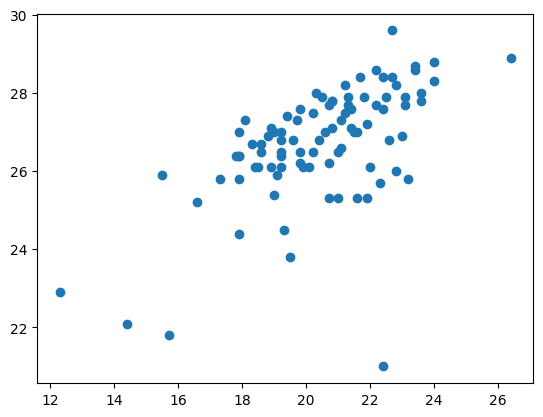

In [6]:
plt.scatter(df['General Health'], df['Depression'])
plt.show()

This dataset has too many columns. Transform all the health indicator columns into rows. Each county should have an individual row for each indicator. You will need two new columns, one for the health indicator name, and one for the corresponding value. 

In [7]:
df_melted = df.melt(list(df.columns)[:6], list(df.columns)[6:], 'measure', 'adj_prev')
df_melted

,stateabbr,statedesc,countyname,countyfips,totalpopulation,totalpop18plus,measure,adj_prev
0,IN,Indiana,Perry,18123,19209,15282,Health Insurance,8.9
1,IN,Indiana,Tippecanoe,18157,188792,150623,Health Insurance,8.8
2,IN,Indiana,Porter,18127,175335,138304,Health Insurance,8.7
3,IN,Indiana,Hendricks,18063,186387,140883,Health Insurance,7.1
4,IN,Indiana,Kosciusko,18085,80364,61628,Health Insurance,9.6
...,...,...,...,...,...,...,...,...
3675,IN,Indiana,Knox,18083,36070,28282,Lack of Social/Emotional Support,24.2
3676,IN,Indiana,Fulton,18049,20358,15626,Lack of Social/Emotional Support,23.5
3677,IN,Indiana,Sullivan,18153,20757,16872,Lack of Social/Emotional Support,24.0
3678,IN,Indiana,Noble,18113,47430,36001,Lack of Social/Emotional Support,23.9


Using this transformed dataset, create a new table showing the second highest county value for every health indicator.

In [8]:
second_highest = df_melted[['measure', 'adj_prev']].groupby('measure').agg(lambda g: g.sort_values().iloc[1]).reset_index()
second_highest.columns = ['measure', 'second_highest']
second_highest

,measure,second_highest
0,All Teeth Lost,7.0
1,Annual Checkup,75.8
2,Any Disability,24.1
3,Arthritis,22.1
4,Binge Drinking,16.2
5,COPD,5.2
6,Cancer (non-skin) or melanoma,6.5
7,Cholesterol Screening,81.0
8,Cognitive Disability,12.1
9,Colorectal Cancer Screening,54.8


In [2]:

import numpy as np
import pandas as pd
rng = np.random.default_rng(7)
n_visits, n_hosp = 2500, 5
patients = [f"P{str(i).zfill(4)}" for i in rng.integers(1, 900, n_visits)]
visits = [f"V{str(i).zfill(3)}" for i in range(n_visits)]
dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(rng.integers(0, 480, n_visits), unit="D")
sex = rng.choice(["M","F","Male","Female","m","f",""], n_visits, p=[.28,.28,.15,.15,.07,.06,.01])
age = rng.choice(np.append(rng.integers(18, 90, n_visits-25), [999]*25), n_visits)
bmi = rng.choice(np.append(np.round(np.clip(np.normal(28, 6, n_visits-200), 12, 58), 1), [np.nan]*200), n_visits)
smoker = rng.choice(["Yes","No","Unknown"], n_visits, p=[.27,.68,.05])
sbp = rng.integers(90, 200, n_visits); dbp = rng.integers(60, 120, n_visits)
flip = rng.random(n_visits) < 0.03; sbp[flip], dbp[flip] = dbp[flip], sbp[flip]
hba1c = rng.choice(np.append(np.round(np.clip(np.normal(5.8, 1.3, n_visits-30), 3.5, 13.5), 1), [0.1, 25.0]), n_visits)
dx = rng.choice(["none","hypertension","diabetes","both"], n_visits, p=[.5,.22,.18,.10])
hosp_ids = [f"H0{i}" for i in rng.integers(1, n_hosp+1, n_visits)]
regions = rng.choice(["Midwest","Northeast","South","West"], n_visits)
readm = rng.integers(0, 2, n_visits)
steps = rng.choice(np.append(rng.integers(2000, 60000, n_visits-300), [np.nan]*300), n_visits)
hr = rng.integers(50, 110, n_visits)
charges = np.round(np.clip(np.normal(1200, 600, n_visits), 100, 8000), 2)
df = pd.DataFrame({"patient_id":patients,"visit_id":visits,"visit_date":dates,"age":age,"sex":sex,"bmi":bmi,
                   "smoker":smoker,"systolic_bp":sbp,"diastolic_bp":dbp,"hba1c":hba1c,"diagnosis":dx,
                   "hospital_id":hosp_ids,"region":regions,"readmitted_30d":readm,"steps_last_7d":steps,
                   "resting_hr":hr,"total_charges":charges})
# inject duplicates & future dates
dup_idx = rng.choice(df.index, 40, replace=False); df = pd.concat([df, df.loc[dup_idx]], ignore_index=True)
df.loc[rng.choice(df.index, 20, replace=False), "visit_date"] = pd.Timestamp("2026-05-01")
df.to_csv("health_visits.csv", index=False)

hosp = pd.DataFrame({
    "hospital_id":[f"H0{i}" for i in range(1,6)],
    "hospital_name":["City General","River Valley","Coastal Health","North Star","Sunrise Medical"],
    "region":["West","Midwest","South","Northeast","Midwest"],
    "bed_count":[350,220,180,400,150]
})
hosp.to_csv("hospitals.csv", index=False)


AttributeError: module 'numpy' has no attribute 'normal'